# Trapped Ion Emulation

Moving a trapped ion changes its position, but can also leave it oscillating
after the trap stops. Random force impulses add another source of motion. We
first follow a displaced wavepacket in a fixed harmonic well, then move the well
and compare several noise strengths. Position distributions and motional energy
show how coherent transport excitation differs from heating.

This guide uses the standard YAQS installation and Matplotlib. Run the cells in
order in a notebook. For a script, use the entry-point guard in
{doc}`simulator_initialization`.

## 1. Build a harmonic trap on a position grid

Each ion occupies one MPO site, whose local basis consists of position-grid
points. `MPO.trapped_ion` combines a finite-difference kinetic operator with a
harmonic potential centered at `trap_center`. We use one ion and dimensionless
units with $\hbar=m=\omega=1$. Position is in oscillator-length units and time
is in units of $1/\omega$.

In [1]:
import numpy as np

from mqt.yaqs import Hamiltonian, MPO, State

positions = np.linspace(-8.0, 8.0, 65)
grid_dim = len(positions)
grid_spacing = positions[1] - positions[0]
omega = 1.0


def trap_at(center):
    return Hamiltonian.from_mpo(
        MPO.trapped_ion(positions, masses=[1.0], omega=omega, trap_center=center)
    )


def state_at(center):
    packet = np.exp(-0.5 * (positions - center) ** 2).astype(complex)
    packet /= np.linalg.norm(packet)
    return State(
        1, tensors=[packet.reshape(grid_dim, 1, 1)], physical_dimensions=[grid_dim],
    )


static_hamiltonian = trap_at(0.0)
static_state = state_at(1.0)

The normalized Gaussian approximates a displaced oscillator ground state. Its
components are amplitudes on the finite grid, so their squared magnitudes sum to
one. A single MPS tensor has shape `(grid_dim, 1, 1)`: one physical index and
two bond indices. This representation supports both the fixed and moving
Hamiltonians below. Supplying `vector=` instead selects the MCWF backend, which
does not support piecewise Hamiltonians.

## 2. Follow an oscillating wavepacket

Measure the mean position and the population of every grid point. The latter
uses projectors $|x_j\rangle\langle x_j|$ and gives a position distribution at
each sampled time, without requesting a sequence of output states.

In [2]:
from mqt.yaqs import AnalogSimParams, Observable, Simulator

position_observable = Observable("position", 0, positions=positions)
grid_projectors = [Observable(np.diag(row), 0) for row in np.eye(grid_dim)]
period = 2 * np.pi / omega
static_params = AnalogSimParams(
    observables=[position_observable, *grid_projectors],
    elapsed_time=period,
    dt=period / 80,
    preset="balanced",
)
simulator = Simulator(show_progress=False)
static_result = simulator.run(static_state, static_hamiltonian, static_params)
static_times = static_result.times
static_values = np.asarray(static_result.expectation_values)
static_density = static_values[1:] / grid_spacing

`expectation_values` follows the supplied observable order. Stacking these
arrays gives shape `(66, 81)`: the mean position, then 65 grid populations.
Divide populations by the grid spacing to plot probability density per unit
position. In the continuum, the mean follows $\langle x(t)\rangle=\cos t$. That
curve is a useful comparison; the finite-difference Hamiltonian differs slightly
from the continuum oscillator.

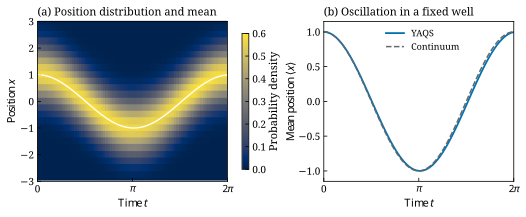

In [3]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["STIXGeneral"], "mathtext.fontset": "stix",
    "font.size": 10, "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in", "svg.fonttype": "none",
    "legend.frameon": False,
})
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), layout="constrained")
image = axes[0].pcolormesh(
    static_times, positions, static_density, shading="auto", cmap="cividis",
    vmin=0, vmax=0.6, rasterized=True,
)
axes[0].plot(static_times, static_values[0], color="white", linewidth=1.3)
axes[0].set(ylabel=r"Position $x$", ylim=(-3, 3))
axes[0].set_title("(a) Position distribution and mean", loc="left", fontsize=11)
fig.colorbar(image, ax=axes[0], label="Probability density", shrink=0.85)
axes[1].plot(static_times, static_values[0], color="#0072B2", linewidth=1.8, label="YAQS")
axes[1].plot(static_times, np.cos(static_times), color="0.4", linestyle="--", label="Continuum")
axes[1].set(ylabel=r"Mean position $\langle x\rangle$", ylim=(-1.15, 1.15))
axes[1].set_title("(b) Oscillation in a fixed well", loc="left", fontsize=11)
axes[1].legend(fontsize=9)
for ax in axes:
    ax.set(xlabel=r"Time $t$", xlim=(0, period), xticks=[0, np.pi, 2 * np.pi],
           xticklabels=["0", r"$\pi$", r"$2\pi$"])
plt.show()

**The packet oscillates about the trap center.** Its mean nearly follows the
continuum curve over one period. The heatmap contains the actual YAQS grid
populations; the white line marks their mean. Small changes in shape and phase
reflect the finite grid and its kinetic operator.

## 3. Move the well, then hold it fixed

Start a new packet at $q=-1$ and translate the well to $q=1$ over four time
units. The control is a staircase: each trap center remains fixed for `dt=0.1`,
followed by a four-unit hold at the target. This deliberately simple protocol
leaves enough residual motion to see in the position distribution.

In [4]:
start_center = -1.0
target_center = 1.0
transport_duration = 4.0
hold_duration = 4.0
dt = 0.1
n_transport = round(transport_duration / dt)
transport_centers = np.linspace(start_center, target_center, n_transport, endpoint=False)
target_hamiltonian = trap_at(target_center)
moving_hamiltonian = Hamiltonian.piecewise([
    *[(trap_at(center), dt) for center in transport_centers],
    (target_hamiltonian, hold_duration),
])
transport_state = state_at(start_center)

`Hamiltonian.piecewise` selects the well for each interval. Piece durations must
be integer multiples of the simulation timestep, and their sum must equal
`elapsed_time`. Piecewise evolution currently requires an MPS and TDVP, which
are used here. Reducing `dt` while rebuilding the staircase also changes the
control waveform; it is a separate check from refining the spatial grid.

## 4. Measure residual motion and heating

Alongside the mean and grid populations, measure $\langle x^2\rangle$ and the
energy of the final well. The ensemble position width is
$\sigma_x=\sqrt{\langle x^2\rangle-\langle x\rangle^2}$. During the hold, the
final-well energy measures motion left by transport and added by noise.

In [5]:
transport_params = AnalogSimParams(
    observables=[
        position_observable,
        Observable(np.diag(positions**2), 0),
        Observable(target_hamiltonian.to_matrix(), 0),
        *grid_projectors,
    ],
    elapsed_time=transport_duration + hold_duration,
    dt=dt,
    order=2,
    num_traj=32,
    preset="balanced",
    random_seed=7,
)
noiseless = simulator.run(transport_state, moving_hamiltonian, transport_params)
times = noiseless.times

The observable arrays have shape `(68, 81)`: mean position, mean squared
position, final-well energy, then grid populations. The `balanced` preset sets
numerical tolerances. Second-order TJM averages 32 trajectories for each noisy
run below; the noiseless baseline needs only one trajectory.

## 5. Add random momentum kicks

Model random force impulses as momentum kicks in either direction. Multiplying
the wavefunction by $e^{\pm i\kappa x}$ shifts its momentum by $\pm\kappa$ in
our units. The two custom jumps are $L_\pm=\sqrt{\gamma/2}\,e^{\pm i\kappa X}$,
where $X=\operatorname{diag}(x_j)$ and $\kappa=1$. Equal rates give no preferred
direction. The kicks heat the ion without friction or thermal relaxation.

In [6]:
from mqt.yaqs import NoiseModel

noise_rates = [0.1, 0.4, 1.0]
kick_size = 1.0
results = {0.0: noiseless}
for rate in noise_rates:
    noise = NoiseModel([
        {"name": "momentum_kick", "sites": [0], "strength": rate / 2,
         "matrix": np.diag(np.exp(1j * sign * kick_size * positions))}
        for sign in (-1, 1)
    ])
    results[rate] = simulator.run(transport_state, moving_hamiltonian, transport_params, noise)

YAQS multiplies each supplied matrix by `sqrt(strength)`. Each direction has
rate $\gamma/2$, so $\gamma$ is the total kick rate in oscillator units. The
noise acts throughout transport and the hold, while the initial state, control
waveform, time grid, and numerical settings stay fixed. The stronger rates make
spreading visible over this short protocol. The grid extends to $x=\pm8$ to
leave room for the heated packet.

Parallel execution is enabled by default. The documentation suppresses progress
bars with `show_progress=False`; omit that setting to see progress. The seed
fixes random streams for the same configuration, and each run preserves the
input state.

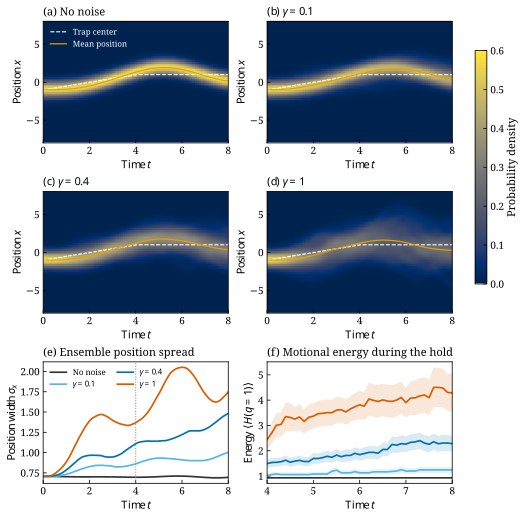

In [7]:
from matplotlib.colors import Normalize

colors = ["0.2", "#56B4E9", "#0072B2", "#D55E00"]
n_hold = round(hold_duration / dt)
scheduled_centers = np.r_[transport_centers, np.full(n_hold + 1, target_center)]
hold_mask = times >= transport_duration
fig, axes = plt.subplots(3, 2, figsize=(7.2, 7.1), layout="constrained")
for index, (ax, (rate, result)) in enumerate(zip(axes[:2].flat, results.items(), strict=True)):
    means = np.asarray(result.expectation_values)
    density = means[3:] / grid_spacing
    image = ax.pcolormesh(times, positions, density, shading="auto", cmap="cividis",
                          norm=Normalize(0, 0.6), rasterized=True)
    ax.step(times, scheduled_centers, where="post", color="white", linestyle="--",
            linewidth=1.1, label="Trap center")
    ax.plot(times, means[0], color="#E69F00", linewidth=1.2, label="Mean position")
    title = "(a) No noise" if index == 0 else rf"({chr(97 + index)}) $\gamma={rate:g}$"
    ax.set(xlabel=r"Time $t$", ylabel=r"Position $x$", xlim=(0, times[-1]), ylim=(-8, 8))
    ax.set_title(title, loc="left", fontsize=11)
    if index == 0:
        ax.legend(loc="upper left", fontsize=8, labelcolor="white")
fig.colorbar(image, ax=list(axes[:2].flat), label="Probability density", shrink=0.8)

for (rate, result), color in zip(results.items(), colors, strict=True):
    means = np.asarray(result.expectation_values)
    samples = result.trajectories[2]
    energy_se = samples.std(axis=0, ddof=1) / np.sqrt(len(samples)) if len(samples) > 1 else np.zeros_like(times)
    width = np.sqrt(means[1] - means[0] ** 2)
    label = "No noise" if rate == 0 else rf"$\gamma={rate:g}$"
    axes[2, 0].plot(times, width, color=color, linewidth=1.7, label=label)
    axes[2, 1].plot(times[hold_mask], means[2, hold_mask], color=color, linewidth=1.7)
    axes[2, 1].fill_between(times[hold_mask], (means[2] - energy_se)[hold_mask],
                            (means[2] + energy_se)[hold_mask], color=color, alpha=0.15, linewidth=0)
axes[2, 0].axvline(transport_duration, color="0.5", linestyle=":", linewidth=1)
axes[2, 0].set(xlabel=r"Time $t$", ylabel=r"Position width $\sigma_x$", xlim=(0, times[-1]))
axes[2, 0].set_title("(e) Ensemble position spread", loc="left", fontsize=11)
axes[2, 0].legend(fontsize=8, ncol=2)
axes[2, 1].set(xlabel=r"Time $t$", ylabel=r"Energy $\langle H(q=1)\rangle$",
                xlim=(transport_duration, times[-1]))
axes[2, 1].set_title("(f) Motional energy during the hold", loc="left", fontsize=11)
plt.show()

**Transport leaves a coherent oscillation; random kicks broaden the packet and
raises its energy.** After $t=4$, the dashed trap center stays fixed while the
mean position continues to oscillate. Without noise, the packet remains narrow
and its energy stays constant during the hold. Stronger noise spreads the
position distribution and increases the motional energy. All heatmaps share one
color scale.

The width in panel (e) describes the ensemble position distribution, including
variation between trajectories. It is not an error bar on the mean position.
Shading in panel (f) shows one standard error of the trajectory-averaged energy.
Thirty-two trajectories make the trend visible, but the curves retain sampling
fluctuations. Increase `num_traj` to resolve smaller differences.

## 6. Adapt the model

Check grid spacing and boundaries before interpreting a quantitative result. The
kinetic operator uses zero exterior boundary values, and a heated packet can
reach the edges. Refine the grid and enlarge its range separately. The continuum
Gaussian is also only an approximate ground state of the discrete Hamiltonian.
For dimensional inputs, pass `hbar` to `MPO.trapped_ion` in units consistent
with the masses, positions, and angular frequency. The kinetic term depends on
$\hbar^2$. For time in seconds, divide one MPO core by $\hbar$ with
`mpo.tensors[0] /= hbar` before wrapping it with `Hamiltonian.from_mpo`. This
converts the energy operator to $H/\hbar$ for YAQS's evolution convention
$\exp(-iH\,dt)$.

A slower or smoother transport protocol can reduce coherent residual motion. The
kick model isolates heating from random impulses. Other noise processes require
suitable jump operators; this model does not describe cooling. The factory
supports one or two ions, with a softened Coulomb interaction for two ions. It
describes motional dynamics on a position grid, rather than internal spin states
or a full laser-driven gate model.

For a noiseless run, `get_state=True` also returns the final state. Noisy MPS
runs return ensemble observables and trajectory data instead of a single final
pure state. Grid projectors remain available for both cases, as shown above.

## Related guides

- {doc}`hamiltonians` — trap parameters, two-ion interactions, and piecewise
  models.
- {doc}`analog_simulation` — noisy evolution, accuracy, and trajectory sampling.
- {doc}`state_initialization` — custom local dimensions and manual MPS tensors.
- {doc}`transmon_emulation` — excitation transfer in a multilevel hardware
  model.